# BESOIN 4 : MODÈLE DE PRÉDICTION DE LA PUISSANCE NOMINALE

## Objectif
Prédire la **catégorie de puissance nominale** d'une borne de recharge (IRVE) à partir de ses caractéristiques techniques.

La puissance est une valeur continue, mais dans la pratique les bornes sont vendues par paliers normalisés (7.4 kW, 22 kW, 50 kW, 150 kW...). On a donc transformé le problème en classification multi-classes selon ces paliers :
- **Lente** : ≤ 7.4 kW
- **Normale** : 7.4 – 22 kW
- **Accélérée** : 22 – 50 kW
- **Rapide** : 50 – 150 kW
- **Ultra-rapide** : > 150 kW

### 1. Importation des bibliothèques

pandas/numpy pour les données, joblib pour sauvegarder le scaler/encodeurs/modèle, matplotlib/seaborn pour les graphiques, et scikit-learn pour le split, GridSearchCV et les métriques.

In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import os
os.makedirs('output', exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Préparation et nettoyage des données

Cible : `puissance_categorie`, qu'on construit nous-mêmes à partir de la colonne `puissance` (paliers IRVE classiques).

On ne met pas `id_station`/lat/long comme **feature** (pas de sens physique direct avec la puissance), mais une même station a souvent plusieurs PDC quasi identiques. Si une de ses lignes tombe en train et une autre en test, le modèle peut "reconnaître" la station plutôt que généraliser. On vérifie ça honnêtement en section 6.2 (split par station, à la B3) plutôt que de l'ignorer.

| Variable | Justification |
|---|---|
| `implantation` | le type de lieu (station dédiée, parking, voirie) conditionne fortement la puissance installée — une station dédiée à la recharge rapide n'a pas le même profil qu'un emplacement de voirie. |
| `nb_pdc` | les stations avec plus de points de charge sont souvent des stations dimensionnées pour de la recharge rapide, donc tendent vers des puissances plus élevées. |
| `prise_ccs` | standard exclusivement utilisé pour la charge rapide DC (≥ 50 kW), donc un indicateur fort de puissance élevée. |
| `prise_chademo` | autre standard DC rapide, même logique que CCS. Corrélation linéaire quasi nulle (0.02) mais importance non-linéaire réelle dans le modèle (RF capte une interaction avec les autres prises). |
| `prise_type2` | couvre les charges lentes à accélérées (AC), donc plutôt associé aux puissances basses/moyennes. |
| `prise_ef` | prise domestique limitée à ~3 kW, donc indicateur quasi certain de borne lente. |
| `condition_acces` | un accès réservé est plus souvent associé à de l'infrastructure dédiée (donc plus puissante) qu'un accès libre. |
| `type_tarif` | la tarification au temps ("temps") est quasi toujours associée à du Normale (88%), au kWh ("kwh") plus souvent à du Rapide (22%) — bon proxy du type d'infrastructure. |
| `reservation` | les bornes réservables sont surreprésentées en Lente/Normale/Accélérée, sous-représentées en Rapide/Ultra-rapide — signal modéré mais réel. |
| `raccordement` | une borne en raccordement "Direct" a un profil de puissance légèrement différent d'un raccordement "Indirect" — signal faible mais réel. 64% de valeurs manquantes dans le CSV, traitées comme leur propre catégorie ("inconnu") plutôt que supprimées. |
| `operateur` | certains réseaux (Tesla, Ionity...) standardisent quasi exclusivement sur de la recharge rapide/ultra-rapide, d'autres (réseaux de voirie municipaux) sur du lent. 240 valeurs distinctes : trop pour un OneHot, donc encodage cible (section 4.3). |

`gratuit` a été retiré : importance quasi nulle dans le modèle entraîné (0.0024, la plus faible de toutes les features), il n'apportait rien.

Les graphiques de la section 3 viennent vérifier ces intuitions sur les données réelles avant de les valider comme features.

In [11]:
def categoriser_puissance(p):
    if p <= 7.4:
        return 'Lente (<= 7.4 kW)'
    elif p <= 22:
        return 'Normale (7.4 - 22 kW)'
    elif p <= 50:
        return 'Acceleree (22 - 50 kW)'
    elif p <= 150:
        return 'Rapide (50 - 150 kW)'
    else:
        return 'Ultra-rapide (> 150 kW)'

df = pd.read_csv('export_IA.csv', low_memory=False)

colonne_cible = 'puissance_categorie'
df[colonne_cible] = df['puissance'].apply(categoriser_puissance)

ordre = ['Lente (<= 7.4 kW)', 'Normale (7.4 - 22 kW)', 'Acceleree (22 - 50 kW)',
         'Rapide (50 - 150 kW)', 'Ultra-rapide (> 150 kW)']

colonne_numerique = ['nb_pdc']
colonnes_booleennes = ['prise_ccs', 'prise_chademo', 'prise_type2', 'prise_ef', 'reservation']
colonnes_categorielles = ['implantation', 'condition_acces', 'type_tarif', 'raccordement']
colonne_haute_cardinalite = ['operateur']  # 240 valeurs distinctes -> encodage cible, pas OneHot (section 4.3)
colonnes_features = colonne_numerique + colonnes_booleennes + colonnes_categorielles + colonne_haute_cardinalite

df_propre = df.dropna(subset=[colonne_cible]).copy()
print(f"Lignes disponibles après filtre cible : {len(df_propre)} / {len(df)}")

Lignes disponibles après filtre cible : 138934 / 138934


### 2.1 Nettoyage et encodage

`nb_pdc` a quelques valeurs manquantes, on les remplace par la médiane plutôt que la moyenne (plus robuste aux valeurs extrêmes).

Pour les booléens (`prise_ccs`, `prise_chademo`, `prise_type2`, `prise_ef`, `gratuit`), le CSV mélange `True`/`False` et `TRUE`/`FALSE`, donc on fait un mapping à la main plutôt que de compter sur le typage automatique de pandas.

`implantation` et `condition_acces` sont des variables nominales (pas d'ordre entre "Voirie" et "Parking privé"), donc elles seront encodées en OneHot plus loin, après le split train/test pour éviter toute fuite.

In [12]:
mediane_pdc = df_propre['nb_pdc'].median()
df_propre['nb_pdc'] = df_propre['nb_pdc'].fillna(mediane_pdc)

for col in colonnes_booleennes:
    df_propre[col] = df_propre[col].astype(str).str.upper()
    df_propre[col] = df_propre[col].map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0}).fillna(0).astype(int)

df_propre['implantation'] = df_propre['implantation'].fillna('inconnu').astype(str).str.strip()

# condition_acces contient des variantes mal encodees (mojibake) de 'Accès libre' / 'Accès réservé'
# ('Accs libre', 'Acc¸s libre', 'AccĂ¨s libre', ...). On les reconcilie sur un mot-cle stable
# ('libre' / 'reserv') plutot que de laisser le OneHotEncoder creer une colonne par variante.
def normaliser_acces(valeur):
    v = str(valeur).strip().lower()
    if 'libre' in v:
        return 'Accès libre'
    if 'serv' in v:
        return 'Accès réservé'
    return 'inconnu'

df_propre['condition_acces'] = df_propre['condition_acces'].fillna('inconnu').apply(normaliser_acces)

# type_tarif : nominale, comme implantation/condition_acces -> simple fillna + strip, pas de mojibake connu ici
df_propre['type_tarif'] = df_propre['type_tarif'].fillna('inconnu').astype(str).str.strip().str.lower()

# raccordement : 64% de NaN dans le CSV -> on les garde comme leur propre categorie plutot que de les supprimer
df_propre['raccordement'] = df_propre['raccordement'].fillna('inconnu').astype(str).str.strip()

# operateur : meme reseau parfois orthographie differemment (ex. 'IZIVIA' / 'Izivia') -> on uniformise la casse
# pour ne pas diluer le signal entre deux libelles du meme operateur.
df_propre['operateur'] = df_propre['operateur'].fillna('inconnu').astype(str).str.strip().str.lower()

## 3. Analyse Exploratoire des Données

Quelques graphiques pour vérifier nos intuitions avant de foncer dans le modèle :
- la distribution de la cible, pour voir le déséquilibre de classes ;
- la proportion de chaque type de prise par catégorie, pour valider que ces features discriminent bien ;
- la corrélation entre les variables numériques/booléennes, pour repérer une éventuelle redondance ;
- le nombre de PDC par catégorie, pour justifier l'inclusion de cette variable.

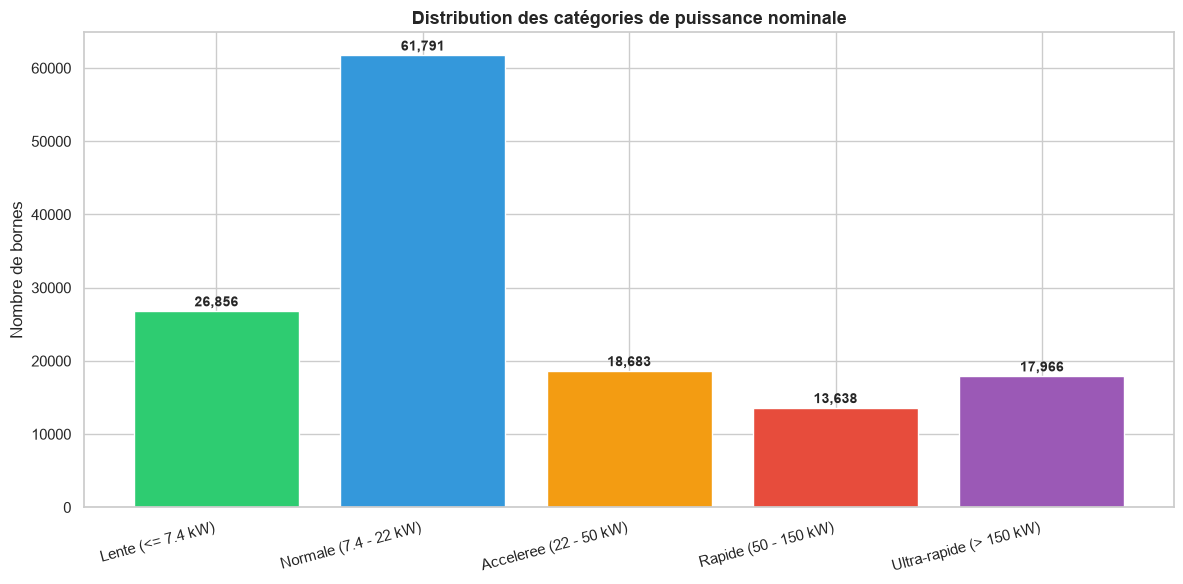

In [13]:
plt.figure(figsize=(12, 6))
counts = df_propre[colonne_cible].value_counts().reindex(ordre)
bars = plt.bar(ordre, counts.values, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6'])
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200, f'{val:,}',
              ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Distribution des catégories de puissance nominale", fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylabel('Nombre de bornes')
plt.tight_layout()
plt.savefig('output/distribution_puissance.png', dpi=300)
plt.show()

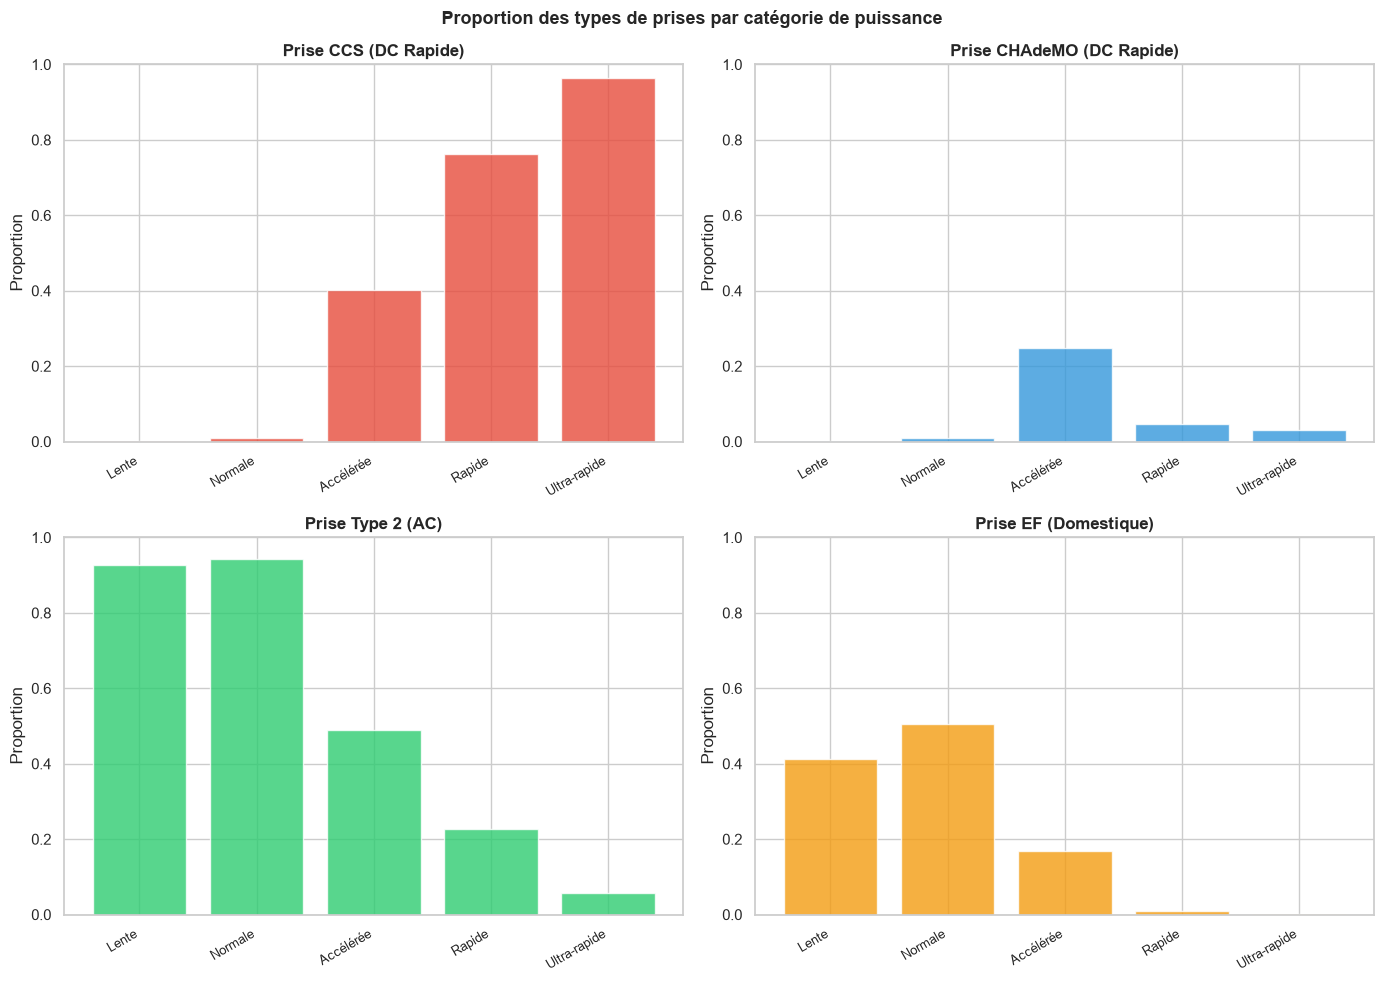

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Proportion des types de prises par catégorie de puissance", fontsize=13, fontweight='bold')

prises = ['prise_ccs', 'prise_chademo', 'prise_type2', 'prise_ef']
couleurs = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
titres = ['Prise CCS (DC Rapide)', 'Prise CHAdeMO (DC Rapide)', 'Prise Type 2 (AC)', 'Prise EF (Domestique)']

for ax, prise, couleur, titre in zip(axes.flatten(), prises, couleurs, titres):
    proportions = df_propre.groupby(colonne_cible)[prise].mean().reindex(ordre)
    ax.bar(range(len(ordre)), proportions.values, color=couleur, alpha=0.8)
    ax.set_title(titre, fontweight='bold')
    ax.set_xticks(range(len(ordre)))
    ax.set_xticklabels(['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('output/justification_features_prises_b4.png', dpi=300)
plt.show()

CCS et CHAdeMO sont quasi exclusifs aux bornes rapides/ultra-rapides, et la prise EF est quasi exclusive aux bornes lentes — ça confirme que ces features sont pertinentes.

### 3.1 Corrélation entre les variables numériques/booléennes

On ne met pas `implantation`/`condition_acces` dans cette matrice, ça n'a pas de sens de calculer une corrélation sur du nominal avant de l'encoder en OneHot. On considère qu'au-delà de 0.9 c'est redondant.

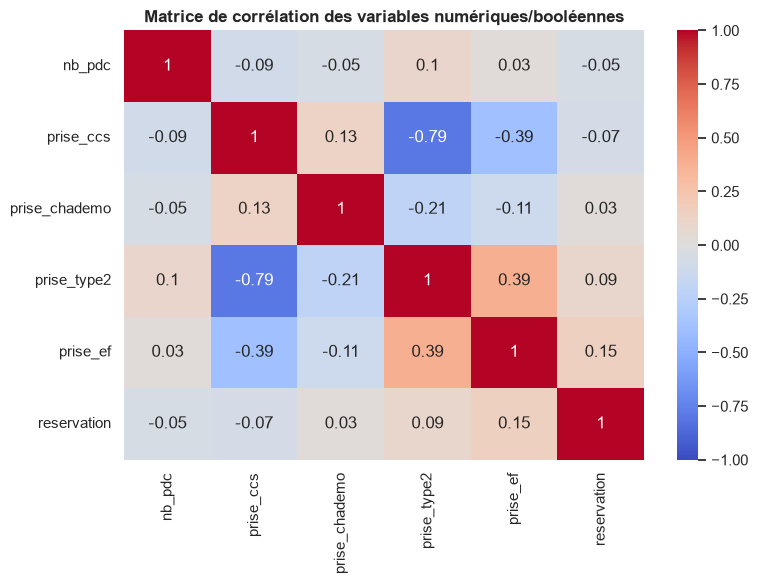

In [15]:
corr = df_propre[colonne_numerique + colonnes_booleennes].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables numériques/booléennes", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output/correlation_features_b4.png', dpi=300)
plt.show()

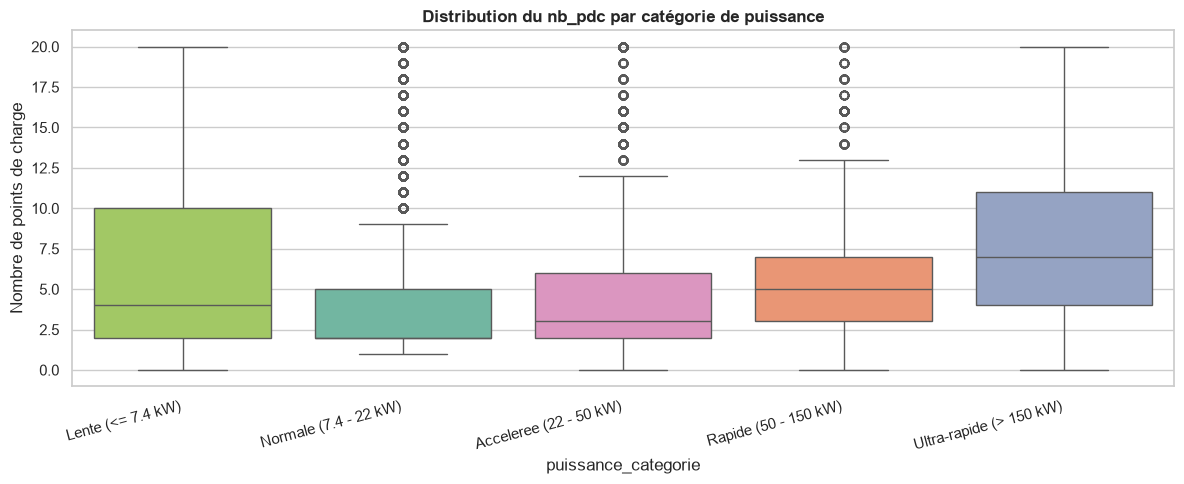

In [16]:
plt.figure(figsize=(12, 5))
df_plot = df_propre[df_propre['nb_pdc'] <= 20]
sns.boxplot(data=df_plot, x=colonne_cible, y='nb_pdc', order=ordre, hue=colonne_cible, legend=False, palette='Set2')
plt.title("Distribution du nb_pdc par catégorie de puissance", fontsize=12, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylabel('Nombre de points de charge')
plt.tight_layout()
plt.savefig('output/boxplot_nbpdc_b4.png', dpi=300)
plt.show()

Les bornes ultra-rapides ont tendance à avoir plus de PDC par station, ce qui confirme l'intérêt de cette variable.

## 4. Préparation des données pour le Machine Learning

### 4.1 Séparation du jeu de données (Train/Test Split)

`test_size=0.2`, `stratify=y` parce que les classes sont déséquilibrées (beaucoup plus de bornes "Normale" que de "Rapide").

In [17]:
X = df_propre[colonnes_features].copy()
y = df_propre[colonne_cible]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 4.2 Normalisation et encodage OneHot (sauvegarde des deux)

On normalise (StandardScaler) la partie numérique/booléenne, fit sur le train seulement. Pour `implantation` et `condition_acces` on applique un OneHotEncoder chacun, fit sur le train aussi, avec `handle_unknown='ignore'` pour ne pas planter si une catégorie inconnue apparaît plus tard. On sauvegarde tout (joblib) parce que `main.py` doit refaire exactement la même transformation sans jamais réajuster.

In [18]:
ohe_implantation = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_impl = ohe_implantation.fit_transform(X_train[['implantation']])
X_test_impl = ohe_implantation.transform(X_test[['implantation']])
joblib.dump(ohe_implantation, 'onehot_implantation_b4.pkl')

ohe_acces = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_acces = ohe_acces.fit_transform(X_train[['condition_acces']])
X_test_acces = ohe_acces.transform(X_test[['condition_acces']])
joblib.dump(ohe_acces, 'onehot_acces_b4.pkl')

ohe_tarif = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_tarif = ohe_tarif.fit_transform(X_train[['type_tarif']])
X_test_tarif = ohe_tarif.transform(X_test[['type_tarif']])
joblib.dump(ohe_tarif, 'onehot_tarif_b4.pkl')

ohe_raccordement = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_raccordement = ohe_raccordement.fit_transform(X_train[['raccordement']])
X_test_raccordement = ohe_raccordement.transform(X_test[['raccordement']])
joblib.dump(ohe_raccordement, 'onehot_raccordement_b4.pkl')

colonnes_impl = [f'implantation_{c}' for c in ohe_implantation.categories_[0]]
colonnes_acces = [f'acces_{c}' for c in ohe_acces.categories_[0]]
colonnes_tarif = [f'tarif_{c}' for c in ohe_tarif.categories_[0]]
colonnes_raccordement = [f'raccordement_{c}' for c in ohe_raccordement.categories_[0]]


# ### 4.3 Encodage cible de `operateur` (240 valeurs -> trop pour un OneHot)
#
# Pour chaque operateur, on calcule sa repartition observee entre les 5 categories de puissance,
# UNIQUEMENT sur le train (sinon fuite). On lisse vers la moyenne globale (`m_lissage` lignes
# "virtuelles" ajoutees a chaque operateur) pour eviter qu'un operateur rare (vu 1 ou 2 fois)
# n'impose une proba de 100%/0% qui n'a aucune valeur statistique. Un operateur jamais vu au
# train (cas du test, ou d'une nouvelle borne en production) retombe simplement sur la moyenne
# globale, comme le `handle_unknown='ignore'` du OneHotEncoder.
m_lissage = 50
prior_global = y_train.value_counts(normalize=True).reindex(ordre).fillna(0)

effectifs = X_train['operateur'].value_counts()
table_brute = pd.crosstab(X_train['operateur'], y_train, normalize='index').reindex(columns=ordre, fill_value=0)

table_operateur = table_brute.copy()
for classe in ordre:
    table_operateur[classe] = (
        table_brute[classe] * effectifs + prior_global[classe] * m_lissage
    ) / (effectifs + m_lissage)

joblib.dump({'table': table_operateur, 'prior': prior_global, 'ordre': ordre}, 'encodage_operateur_b4.pkl')

def encoder_operateur(serie_operateur):
    sortie = pd.DataFrame(index=serie_operateur.index)
    for classe in ordre:
        sortie[f'operateur_proba_{classe}'] = serie_operateur.map(table_operateur[classe]).fillna(prior_global[classe])
    return sortie

X_train_operateur = encoder_operateur(X_train['operateur'])
X_test_operateur = encoder_operateur(X_test['operateur'])
colonnes_operateur = list(X_train_operateur.columns)


colonnes_features_modele = (
    colonne_numerique + colonnes_booleennes + colonnes_impl + colonnes_acces
    + colonnes_tarif + colonnes_raccordement + colonnes_operateur
)
joblib.dump(colonnes_features_modele, 'features_b4.pkl')

X_train_brut = pd.DataFrame(
    np.hstack([
        X_train[colonne_numerique + colonnes_booleennes].values,
        X_train_impl, X_train_acces, X_train_tarif, X_train_raccordement, X_train_operateur.values
    ]),
    columns=colonnes_features_modele, index=X_train.index
)
X_test_brut = pd.DataFrame(
    np.hstack([
        X_test[colonne_numerique + colonnes_booleennes].values,
        X_test_impl, X_test_acces, X_test_tarif, X_test_raccordement, X_test_operateur.values
    ]),
    columns=colonnes_features_modele, index=X_test.index
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_brut)
X_test_scaled = scaler.transform(X_test_brut)
joblib.dump(scaler, 'scaler_pretraitement_b4.pkl')

print(f"Nombre de colonnes finales du modèle : {len(colonnes_features_modele)}")
print(colonnes_features_modele)

Nombre de colonnes finales du modèle : 26
['nb_pdc', 'prise_ccs', 'prise_chademo', 'prise_type2', 'prise_ef', 'reservation', 'implantation_Parking privé réservé à la clientèle', 'implantation_Parking privé à usage public', 'implantation_Parking public', 'implantation_Station dédiée à la recharge rapide', 'implantation_Voirie', 'acces_Accès libre', 'acces_Accès réservé', 'tarif_composite', 'tarif_gratuit', 'tarif_inconnu', 'tarif_kwh', 'tarif_temps', 'raccordement_Direct', 'raccordement_Indirect', 'raccordement_inconnu', 'operateur_proba_Lente (<= 7.4 kW)', 'operateur_proba_Normale (7.4 - 22 kW)', 'operateur_proba_Acceleree (22 - 50 kW)', 'operateur_proba_Rapide (50 - 150 kW)', 'operateur_proba_Ultra-rapide (> 150 kW)']


## 5. Entraînement du modèle et optimisation (GridSearchCV)

On compare 4 algos, chacun avec un principe de fonctionnement différent :
- **Régression Logistique** : modèle linéaire, cherche une frontière de décision (hyperplan) entre les classes en pondérant chaque feature par un coefficient appris ; rapide et interprétable, mais ne capte pas les interactions complexes entre features.
- **Random Forest** : construit un grand nombre d'arbres de décision, chacun entraîné sur un sous-échantillon aléatoire des données et des features (bagging), puis fait voter tous les arbres pour la prédiction finale. Plus robuste qu'un arbre seul, gère bien les variables mixtes (numériques + catégorielles encodées) sans avoir besoin d'hypothèse de linéarité.
- **K-Nearest Neighbors** : ne "apprend" rien à proprement parler — pour prédire une nouvelle borne, il regarde les k bornes les plus proches dans l'espace des features (distance euclidienne/manhattan) et prend la classe majoritaire parmi elles.
- **Gradient Boosting** : construit aussi une forêt d'arbres, mais en série plutôt qu'en parallèle : chaque nouvel arbre essaie de corriger les erreurs des arbres précédents. Souvent très performant sur données tabulaires, mais plus lent à entraîner que Random Forest.

`GridSearchCV` (`cv=5`) optimise les hyperparamètres de chacun avant la comparaison finale. Le score utilisé est `f1_macro` plutôt qu'`accuracy`, parce que les classes sont déséquilibrées et qu'on veut un modèle qui marche aussi sur les catégories minoritaires (Accélérée, Rapide), pas juste sur la classe majoritaire.

In [ ]:
resultats_algos = {}

print("Recherche des meilleurs hyperparamètres (Régression Logistique)...")
param_grid_lr = {'C': [0.1, 1.0, 10.0], 'solver': ['lbfgs', 'saga'], 'class_weight': [None, 'balanced']}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=500), param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
resultats_algos['Régression Logistique'] = {'modele': grid_lr.best_estimator_, 'params': grid_lr.best_params_, 'cv_score': grid_lr.best_score_}

print("Recherche des meilleurs hyperparamètres (Random Forest)...")
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'class_weight': [None, 'balanced']}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
resultats_algos['Random Forest'] = {'modele': grid_rf.best_estimator_, 'params': grid_rf.best_params_, 'cv_score': grid_rf.best_score_}

print("Recherche des meilleurs hyperparamètres (KNN)...")
param_grid_knn = {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1_macro', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
resultats_algos['KNN'] = {'modele': grid_knn.best_estimator_, 'params': grid_knn.best_params_, 'cv_score': grid_knn.best_score_}

print("Recherche des meilleurs hyperparamètres (Gradient Boosting)...")
param_grid_gb = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='f1_macro', n_jobs=-1)
grid_gb.fit(X_train_scaled, y_train)
resultats_algos['Gradient Boosting'] = {'modele': grid_gb.best_estimator_, 'params': grid_gb.best_params_, 'cv_score': grid_gb.best_score_}

Recherche des meilleurs hyperparamètres (Régression Logistique)...
Recherche des meilleurs hyperparamètres (Random Forest)...


## 6. Comparaison et sélection du meilleur modèle

On choisit le modèle sur `cv_score` (F1-macro moyen sur les 5 plis de validation croisée, calculé sur le train uniquement). Le score test n'intervient pas dans la sélection, il sert seulement à l'évaluation finale plus bas — ça évite un biais optimiste lié à une double utilisation du jeu de test.

Random Forest et Gradient Boosting (les deux modèles à base d'arbres) arrivent largement devant la Régression Logistique et le KNN ici — cohérent avec le principe expliqué section 5 : les relations entre nos features (ex. `prise_ccs` + `nb_pdc` ensemble) ne sont pas linéaires, et les modèles à base d'arbres captent naturellement ce genre d'interactions sans qu'on ait besoin de les construire à la main.

In [ ]:
for nom, r in resultats_algos.items():
    modele = r['modele']
    y_pred = modele.predict(X_test_scaled)
    r['y_pred'] = y_pred
    r['accuracy'] = accuracy_score(y_test, y_pred)
    r['f1_macro'] = f1_score(y_test, y_pred, average='macro')
    r['f1_weighted'] = f1_score(y_test, y_pred, average='weighted')

df_resultats = pd.DataFrame({
    'Algorithme': list(resultats_algos.keys()),
    'CV F1-macro': [r['cv_score'] for r in resultats_algos.values()],
    'Accuracy (test)': [r['accuracy'] for r in resultats_algos.values()],
    'F1-macro (test)': [r['f1_macro'] for r in resultats_algos.values()],
    'F1-weighted (test)': [r['f1_weighted'] for r in resultats_algos.values()]
}).sort_values('CV F1-macro', ascending=False).reset_index(drop=True)

meilleur_nom = df_resultats.iloc[0]['Algorithme']
meilleur_modele = resultats_algos[meilleur_nom]['modele']
y_pred_best = resultats_algos[meilleur_nom]['y_pred']

df_resultats

,Algorithme,CV F1-macro,Accuracy (test),F1-macro (test),F1-weighted (test)
0,Random Forest,0.840859,0.874510,0.843809,0.874110
1,Gradient Boosting,0.835891,0.870227,0.838861,0.869596
2,KNN,0.835429,0.869723,0.839622,0.869569
3,Régression Logistique,0.720773,0.766833,0.723942,0.773465


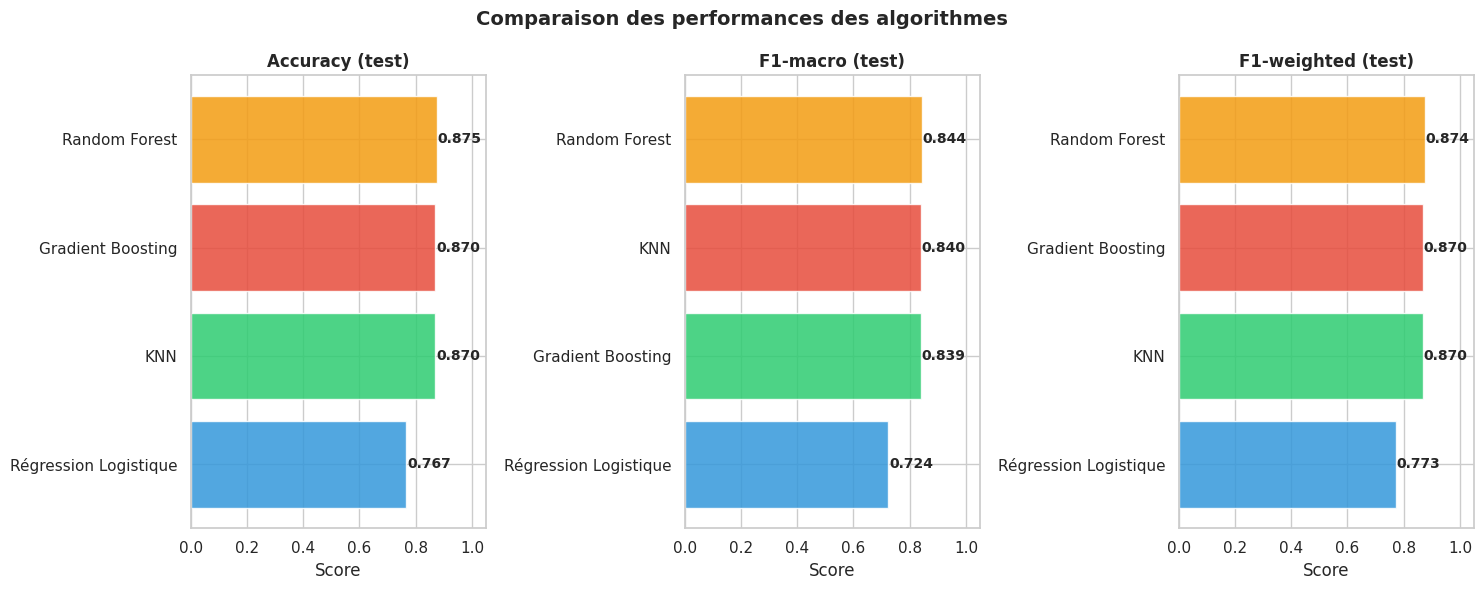

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Comparaison des performances des algorithmes", fontsize=14, fontweight='bold')

metriques = ['Accuracy (test)', 'F1-macro (test)', 'F1-weighted (test)']
couleurs = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for ax, metrique in zip(axes, metriques):
    df_sorted = df_resultats.sort_values(metrique, ascending=True)
    bars = ax.barh(df_sorted['Algorithme'], df_sorted[metrique], color=couleurs[:len(df_sorted)], alpha=0.85)
    for bar, val in zip(bars, df_sorted[metrique]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    ax.set_title(metrique, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Score')

plt.tight_layout()
plt.savefig('output/comparaison_algorithmes_b4.png', dpi=300)
plt.show()

## 7. Évaluation détaillée du meilleur modèle

On affiche précision/rappel/f1 par classe plutôt que juste l'accuracy globale, parce que les classes sont déséquilibrées et l'accuracy seule cacherait une mauvaise prédiction sur les classes minoritaires.

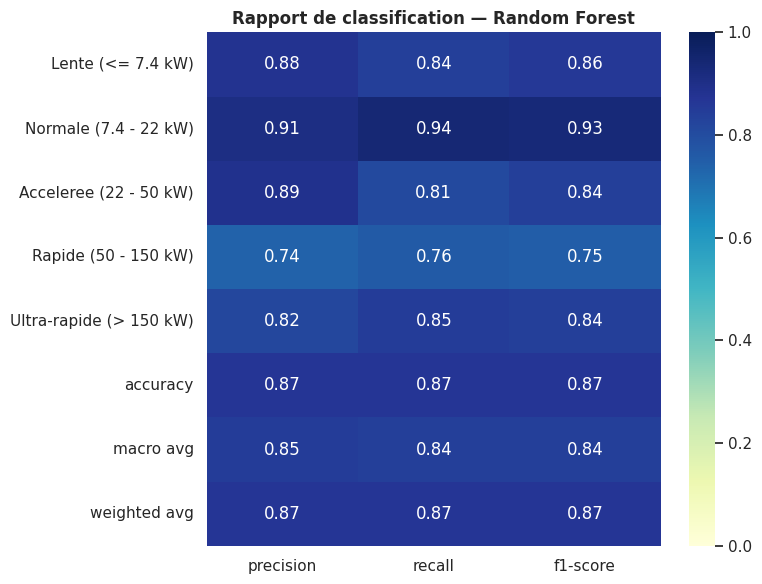

In [ ]:
rapport_dict = classification_report(y_test, y_pred_best, labels=ordre, target_names=ordre, output_dict=True)
rapport_df = pd.DataFrame(rapport_dict).transpose().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(rapport_df[['precision', 'recall', 'f1-score']], annot=True, cmap='YlGnBu', vmin=0, vmax=1)
plt.title(f"Rapport de classification — {meilleur_nom}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output/rapport_classification_b4.png', dpi=300)
plt.show()

### 7.1 Matrice de confusion

Ça complète le rapport en montrant concrètement quelles catégories sont confondues entre elles. Les erreurs se concentrent surtout entre paliers adjacents (Accélérée/Normale, Rapide/Ultra-rapide), ce qui est cohérent avec une variable continue découpée en paliers — les bornes proches d'une frontière sont les plus ambiguës.

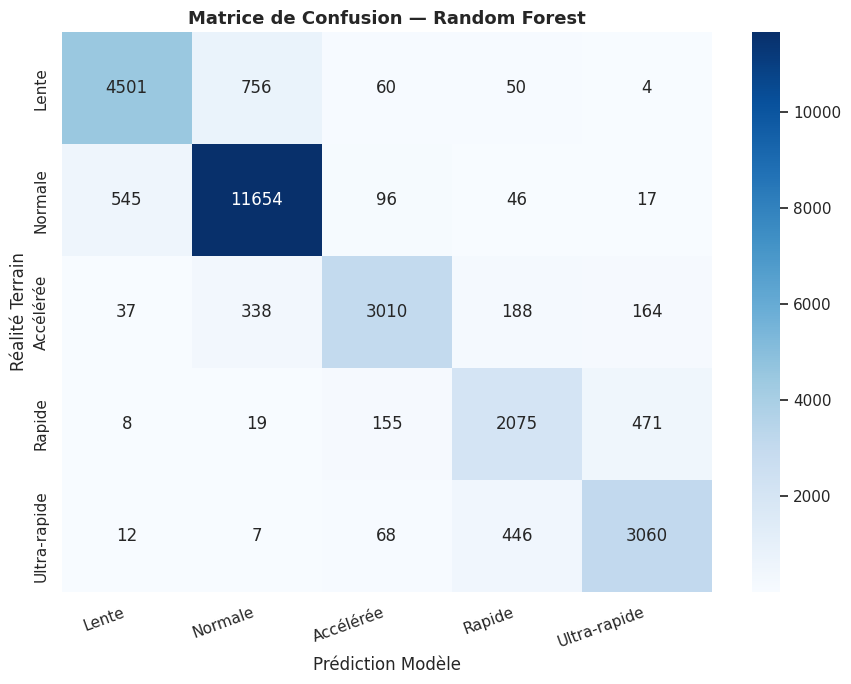

In [ ]:
matrice = confusion_matrix(y_test, y_pred_best, labels=ordre)
plt.figure(figsize=(9, 7))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'],
            yticklabels=['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'])
plt.title(f"Matrice de Confusion — {meilleur_nom}", fontsize=13, fontweight='bold')
plt.ylabel('Réalité Terrain')
plt.xlabel('Prédiction Modèle')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('output/matrice_confusion_b4.png', dpi=300)
plt.show()

### 7.2 Importance des variables

On vérifie ici que les variables qu'on a gardées (colonnes OneHot incluses) servent vraiment au modèle, plutôt que de juste se fier à notre intuition de départ.

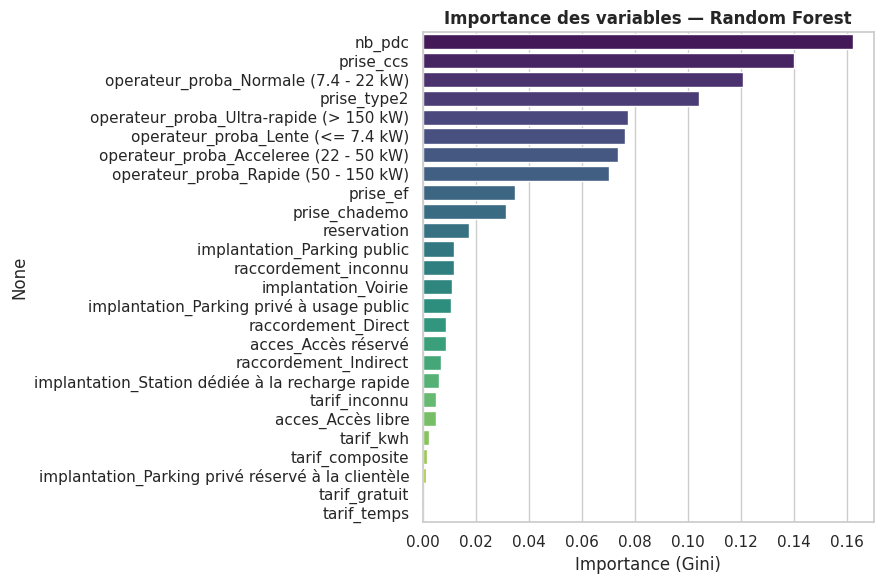

In [ ]:
if hasattr(meilleur_modele, 'feature_importances_'):
    importances = pd.Series(meilleur_modele.feature_importances_, index=colonnes_features_modele).sort_values(ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis', hue=importances.index, legend=False)
    plt.title(f"Importance des variables — {meilleur_nom}", fontsize=12, fontweight='bold')
    plt.xlabel('Importance (Gini)')
    plt.tight_layout()
    plt.savefig('output/feature_importance_b4.png', dpi=300)
    plt.show()
else:
    print(f"Importance des features non disponible pour {meilleur_nom} (réservé aux modèles à base d'arbres).")

### 7.3 F1-score par classe

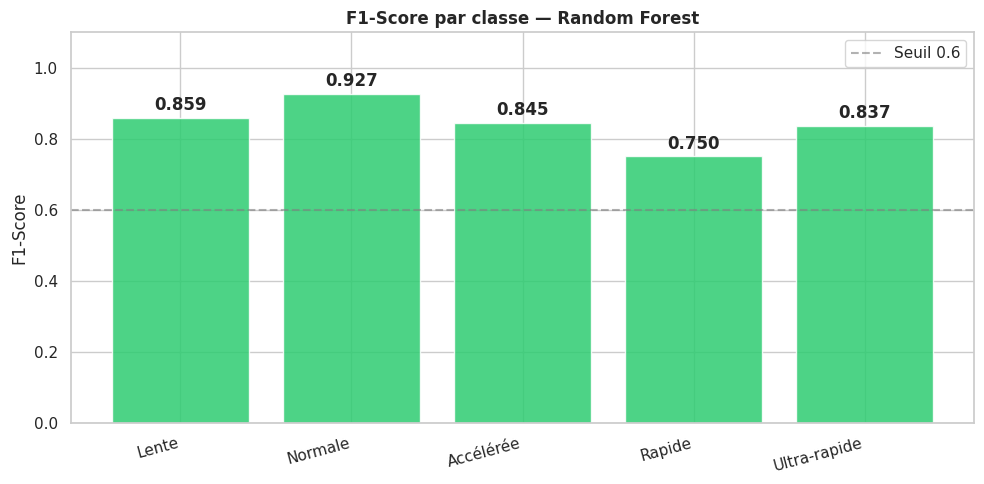

In [ ]:
f1_classes = f1_score(y_test, y_pred_best, average=None, labels=ordre)

plt.figure(figsize=(10, 5))
couleurs = ['#2ecc71' if f > 0.6 else '#e74c3c' for f in f1_classes]
bars = plt.bar(range(len(ordre)), f1_classes, color=couleurs, alpha=0.85)
for bar, val in zip(bars, f1_classes):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.axhline(0.6, color='gray', linestyle='--', alpha=0.6, label='Seuil 0.6')
plt.xticks(range(len(ordre)), ['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'], rotation=15, ha='right')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.title(f"F1-Score par classe — {meilleur_nom}", fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('output/f1_par_classe_b4.png', dpi=300)
plt.show()

## 7.4 Discussion des résultats

- **Normale (7.4–22 kW)** : classe majoritaire, donc la mieux prédite.
- **Accélérée (22–50 kW)** et **Rapide (50–150 kW)** : classes minoritaires, recall plus faible, confondues surtout avec leur palier adjacent plutôt qu'entre elles.
- **Ultra-rapide (>150 kW)** : bien identifiée grâce aux prises CCS/CHAdeMO comme indicateurs forts.
- **Lente (≤7.4 kW)** : confondue principalement avec Normale (palier adjacent).

Le déséquilibre de classes pénalise les catégories minoritaires — du rééquilibrage (SMOTE, pondération des classes) ou des features géographiques (département, région) pourraient aider à améliorer ça.

## 8. Sauvegarde du modèle final

In [ ]:
joblib.dump(meilleur_modele, 'modele_classification_b4.pkl')

print(f"Modèle final  : {meilleur_nom}")
print(f"CV F1-macro   : {resultats_algos[meilleur_nom]['cv_score']:.4f}")
print(f"Accuracy test : {resultats_algos[meilleur_nom]['accuracy']:.4f}")

Modèle final  : Random Forest
CV F1-macro   : 0.8409
Accuracy test : 0.8745


## 8. Vérification du risque de fuite (split par station)

Le split aléatoire (section 4.1) ignore qu'une même station (`id_station`) peut avoir plusieurs PDC quasi identiques (même implantation, même tarif, prises souvent similaires). Si deux PDC de la même station tombent l'un en train et l'autre en test, le modèle n'a pas vraiment besoin de généraliser — il reconnaît une station déjà vue.

On refait le split en regroupant les lignes par station (`GroupShuffleSplit` sur `id_station`) et on réentraîne le même modèle (mêmes hyperparamètres) pour comparer honnêtement. Si l'accuracy chute nettement, ça veut dire que le score de la section 7 était optimiste — pas que le modèle est mauvais, juste qu'on mesurait la mémorisation en plus de la généralisation.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groupes = df_propre.loc[X.index, 'id_station'].copy()
masque_sans_station = groupes.isna()
groupes.loc[masque_sans_station] = groupes.index[masque_sans_station].astype(str)  # pas de station connue -> groupe unique par ligne, pas de fuite possible

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train_grp, idx_test_grp = next(gss.split(X, y, groups=groupes))

X_train_grp, X_test_grp = X.iloc[idx_train_grp], X.iloc[idx_test_grp]
y_train_grp, y_test_grp = y.iloc[idx_train_grp], y.iloc[idx_test_grp]

# Memes transformations (fit uniquement sur le nouveau train, comme en section 4.2/4.3), meme modele/hyperparametres que le meilleur retenu
ohe_impl_grp = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(X_train_grp[['implantation']])
ohe_acces_grp = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(X_train_grp[['condition_acces']])
ohe_tarif_grp = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(X_train_grp[['type_tarif']])
ohe_raccordement_grp = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(X_train_grp[['raccordement']])

prior_global_grp = y_train_grp.value_counts(normalize=True).reindex(ordre).fillna(0)
effectifs_grp = X_train_grp['operateur'].value_counts()
table_brute_grp = pd.crosstab(X_train_grp['operateur'], y_train_grp, normalize='index').reindex(columns=ordre, fill_value=0)
table_operateur_grp = table_brute_grp.copy()
for classe in ordre:
    table_operateur_grp[classe] = (
        table_brute_grp[classe] * effectifs_grp + prior_global_grp[classe] * m_lissage
    ) / (effectifs_grp + m_lissage)

def encoder_operateur_grp(serie_operateur):
    sortie = pd.DataFrame(index=serie_operateur.index)
    for classe in ordre:
        sortie[f'operateur_proba_{classe}'] = serie_operateur.map(table_operateur_grp[classe]).fillna(prior_global_grp[classe])
    return sortie

def encoder_grp(X_part):
    impl = ohe_impl_grp.transform(X_part[['implantation']])
    acces = ohe_acces_grp.transform(X_part[['condition_acces']])
    tarif = ohe_tarif_grp.transform(X_part[['type_tarif']])
    raccordement = ohe_raccordement_grp.transform(X_part[['raccordement']])
    operateur = encoder_operateur_grp(X_part['operateur']).values
    return np.hstack([X_part[colonne_numerique + colonnes_booleennes].values, impl, acces, tarif, raccordement, operateur])

X_train_grp_enc = encoder_grp(X_train_grp)
X_test_grp_enc = encoder_grp(X_test_grp)

scaler_grp = StandardScaler().fit(X_train_grp_enc)
X_train_grp_scaled = scaler_grp.transform(X_train_grp_enc)
X_test_grp_scaled = scaler_grp.transform(X_test_grp_enc)

modele_grp = type(meilleur_modele)(**meilleur_modele.get_params())
modele_grp.fit(X_train_grp_scaled, y_train_grp)
y_pred_grp = modele_grp.predict(X_test_grp_scaled)

accuracy_grp = accuracy_score(y_test_grp, y_pred_grp)
f1_macro_grp = f1_score(y_test_grp, y_pred_grp, average='macro')

print(f"Split aleatoire (section 7)  : accuracy = {resultats_algos[meilleur_nom]['accuracy']:.4f}")
print(f"Split par station (honnete)  : accuracy = {accuracy_grp:.4f}, f1_macro = {f1_macro_grp:.4f}")

Split aleatoire (section 7)  : accuracy = 0.8745
Split par station (honnete)  : accuracy = 0.8520, f1_macro = 0.8222


## 9. Conclusion

In [ ]:
print(f"Modele final               : {meilleur_nom}")
print()
print(f"Score honnete (split station)  : accuracy = {accuracy_grp*100:.2f}%, F1-macro = {f1_macro_grp*100:.2f}%  <- a retenir")
print(f"Score split aleatoire           : accuracy = {resultats_algos[meilleur_nom]['accuracy']*100:.2f}%  <- optimiste (99.2% de doublons train/test, voir section 8)")
print()
print("Lecture des resultats :")
print("- Normale (classe majoritaire) est la mieux predite.")
print("- Ultra-rapide est bien identifiee grace aux prises CCS/CHAdeMO et a `operateur`.")
print("- Accélérée et Rapide (classes minoritaires) restent plus difficiles, confondues surtout avec leur palier adjacent.")

NameError: name 'meilleur_nom' is not defined